# 🏛️ Institute Command Centre — April 2026
> **Live snapshot** · Students · Admissions · Attendance · Placement · Staff · Courses · Classroom

In [1]:
# ─────────────────────────────────────────────────────────────────────
# CELL 1 · Imports & Data Load
# ─────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ── Load datasets ──────────────────────────────────────────────────────
admissions   = pd.read_csv('admission.csv')
students     = pd.read_csv('students.csv')
attendance   = pd.read_csv('attendance_current_month.csv')
placement    = pd.read_csv('placement.csv')
staff        = pd.read_csv('staff_dataset.csv')
classroom    = pd.read_csv('classroom.csv')
courses      = pd.read_csv('course_dataset.csv')
schedule     = pd.read_csv('staff_schedule_with_weekly.csv')

print('✅ All 8 datasets loaded successfully!')
print(f'   Admissions : {len(admissions):>4} records')
print(f'   Students   : {len(students):>4} records')
print(f'   Attendance : {len(attendance):>4} records')
print(f'   Placement  : {len(placement):>4} records')
print(f'   Staff      : {len(staff):>4} records')
print(f'   Classroom  : {len(classroom):>4} records')
print(f'   Courses    : {len(courses):>4} records')
print(f'   Schedule   : {len(schedule):>4} records')

✅ All 8 datasets loaded successfully!
   Admissions :  474 records
   Students   :  200 records
   Attendance :  200 records
   Placement  :  200 records
   Staff      :   17 records
   Classroom  :    5 records
   Courses    :   11 records
   Schedule   :   11 records


In [2]:
# ─────────────────────────────────────────────────────────────────────
# CELL 2 · KPI Calculations
# ─────────────────────────────────────────────────────────────────────

# KPI 1 – Total Students
total_students = len(students)

# KPI 2 – Admission Rate  (Admitted / Total enquiries)
total_enquiries = len(admissions)
admitted        = (admissions['status'] == 'Admitted').sum()
adm_rate        = round(admitted / total_enquiries * 100, 1)

# KPI 3 – Placement Rate  (Placed / Total students)
placed          = (placement['status'] == 'Placed').sum()
placed_pct      = round(placed / len(placement) * 100, 1)

# KPI 4 – Average Attendance
avg_att         = round(attendance['Attendance %'].mean(), 1)

# KPI 5 – Students with Attendance < 75%
below_75        = (attendance['Attendance %'] < 75).sum()

# KPI 6 – Average Package (placed students)
placed_df       = placement[placement['status'] == 'Placed'].copy()
placed_df['package(Rs.L)'] = pd.to_numeric(placed_df['package(Rs.L)'], errors='coerce')
avg_pkg         = round(placed_df['package(Rs.L)'].mean(), 1)

# KPI 7 – Classroom Fill Rate  (slots occupied / total slots)
slot_cols = ['10:00-12:00', '12:00-02:00', '02:30-04:30', '04:30-05:30']
total_slots    = classroom.shape[0] * len(slot_cols)
filled_slots   = classroom[slot_cols].apply(lambda col: col.str.strip().ne('')).sum().sum()
room_fill_pct  = round(filled_slots / total_slots * 100)

# KPI 8 – Total Batches
total_batches  = courses['total_batches'].sum()

kpis = {
    'Total Students'   : (total_students, '👩‍🎓', '#6366f1'),
    'Admission Rate'   : (f'{adm_rate}%', '📋', '#06b6d4'),
    'Placed'           : (f'{placed_pct}%', '🎯', '#10b981'),
    'Avg Attendance'   : (f'{avg_att}%', '📊', '#f59e0b'),
    '<75% Att.'        : (below_75, '⚠️', '#ef4444'),
    'Avg Package'      : (f'{avg_pkg}L', '💰', '#8b5cf6'),
    'Room Fill'        : (f'{room_fill_pct}%', '🏫', '#14b8a6'),
    'Batches'          : (total_batches, '📚', '#f97316'),
}

for k, (v, icon, _) in kpis.items():
    print(f'  {icon}  {k:<20} → {v}')

  👩‍🎓  Total Students       → 200
  📋  Admission Rate       → 42.2%
  🎯  Placed               → 35.5%
  📊  Avg Attendance       → 84.1%
  ⚠️  <75% Att.            → 42
  💰  Avg Package          → 10.9L
  🏫  Room Fill            → 100%
  📚  Batches              → 29


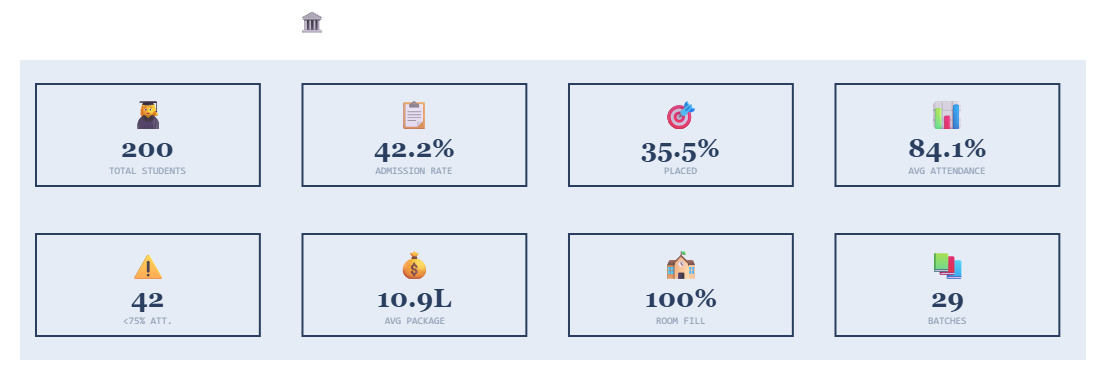

In [3]:
# ─────────────────────────────────────────────────────────────────────
# CELL 3 · 🏆 KPI BANNER  (8 KPI Cards)
# ─────────────────────────────────────────────────────────────────────

labels  = list(kpis.keys())
values  = [str(v) for v, _, _ in kpis.values()]
colors  = [c for _, _, c in kpis.values()]
icons   = [i for _, i, _ in kpis.values()]

fig_kpi = go.Figure()

cols = 4
rows = 2
xs   = [0.12, 0.37, 0.62, 0.87, 0.12, 0.37, 0.62, 0.87]
ys   = [0.75, 0.75, 0.75, 0.75, 0.25, 0.25, 0.25, 0.25]

for i, (label, val, color, icon, x, y) in enumerate(zip(labels, values, colors, icons, xs, ys)):
    # Card background
    fig_kpi.add_shape(type='rect',
        x0=x-0.105, y0=y-0.17, x1=x+0.105, y1=y+0.17,
        line=dict( width=2),
        layer='below')
    # Top accent bar
    fig_kpi.add_shape(type='rect',
        x0=x-0.105, y0=y+0.14, x1=x+0.105, y1=y+0.17,
        line=dict(width=0), layer='below')

    fig_kpi.add_annotation(x=x, y=y+0.07, text=icon, showarrow=False,
        font=dict(size=28), yanchor='middle')
    fig_kpi.add_annotation(x=x, y=y-0.04, text=f'<b>{val}</b>', showarrow=False,
        font=dict(size=26,  family='Georgia'), yanchor='middle')
    fig_kpi.add_annotation(x=x, y=y-0.12, text=label.upper(), showarrow=False,
        font=dict(size=10, color='#94a3b8', family='monospace'), yanchor='middle')

fig_kpi.update_layout(
    title=dict(text='🏛️  INSTITUTE COMMAND CENTRE — April 2026',
               font=dict(size=22, color='white', family='Georgia'),
               x=0.5),
    
    height=380,
    margin=dict(l=20, r=20, t=60, b=20),
    xaxis=dict(visible=False, range=[0,1]),
    yaxis=dict(visible=False, range=[0,1]),
)
fig_kpi.show()

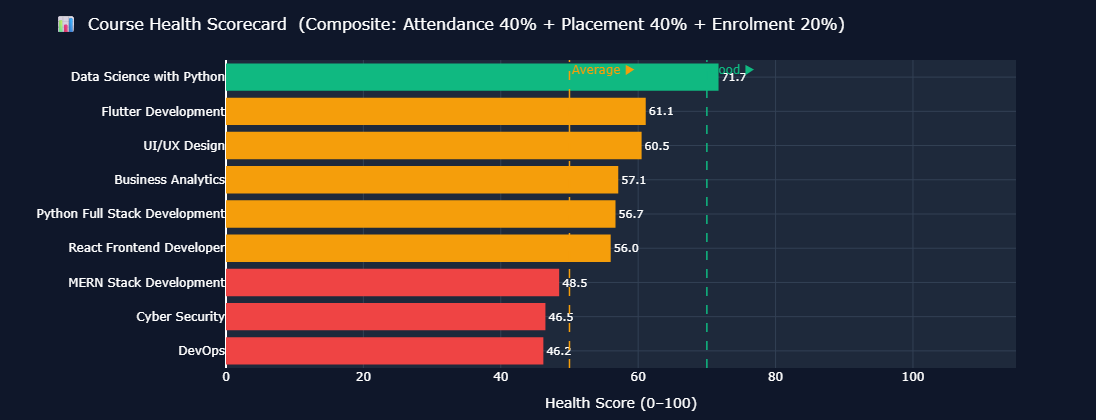

In [19]:
# ─────────────────────────────────────────────────────────────────────
# CELL 4 · 📋 Course Health Scorecard
# ─────────────────────────────────────────────────────────────────────

# Build per-course metrics
course_enroll = students['course'].value_counts().reset_index()
course_enroll.columns = ['course', 'enrolled']

att_by_course = attendance.groupby('course')['Attendance %'].mean().reset_index()
att_by_course.columns = ['course', 'avg_att']

plc_by_course = placement[placement['status']=='Placed'].groupby('course').size().reset_index(name='placed')
total_by_course = placement.groupby('course').size().reset_index(name='total')
plc_rate = plc_by_course.merge(total_by_course, on='course')
plc_rate['plc_pct'] = (plc_rate['placed'] / plc_rate['total'] * 100).round(1)

health = course_enroll.merge(att_by_course, on='course', how='left')
health = health.merge(plc_rate[['course','plc_pct']], on='course', how='left')
health['avg_att'] = health['avg_att'].fillna(0).round(1)
health['plc_pct'] = health['plc_pct'].fillna(0)

# Health score = 0.4*att + 0.4*plc + 0.2*(enrolled/max_enrolled*100)
health['health'] = (
    0.4 * health['avg_att'] +
    0.4 * health['plc_pct'] +
    0.2 * (health['enrolled'] / health['enrolled'].max() * 100)
).round(1)

health = health.sort_values('health', ascending=True)

def health_color(h):
    if h >= 70: return '#10b981'
    if h >= 50: return '#f59e0b'
    return '#ef4444'

bar_colors = [health_color(h) for h in health['health']]

fig_health = go.Figure()
fig_health.add_trace(go.Bar(
    y=health['course'], x=health['health'],
    orientation='h',
    marker=dict(color=bar_colors, line=dict(width=0)),
    text=[f'{h}' for h in health['health']],
    textposition='outside',
    textfont=dict(size=11, color='white'),
    hovertemplate=('<b>%{y}</b><br>Health Score: %{x}<br>'
                   'Enrolled: %{customdata[0]}<br>'
                   'Avg Att: %{customdata[1]}%<br>'
                   'Placed: %{customdata[2]}%<extra></extra>'),
    customdata=health[['enrolled','avg_att','plc_pct']].values
))
fig_health.add_vline(x=70, line=dict(color='#10b981', dash='dash', width=1.5),
    annotation_text='Good ▶', annotation_font_color='#10b981')
fig_health.add_vline(x=50, line=dict(color='#f59e0b', dash='dash', width=1.5),
    annotation_text='Average ▶', annotation_font_color='#f59e0b')

fig_health.update_layout(
    title=dict(text='📊  Course Health Scorecard  (Composite: Attendance 40% + Placement 40% + Enrolment 20%)',
               font=dict(size=16, color='white')),
    paper_bgcolor='#0f172a', plot_bgcolor='#1e293b',
    font=dict(color='white'),
    xaxis=dict(title='Health Score (0–100)', range=[0, 115], gridcolor='#334155'),
    yaxis=dict(title='', gridcolor='#334155'),
    height=420, margin=dict(l=20, r=80, t=60, b=40),
    showlegend=False
)
fig_health.show()

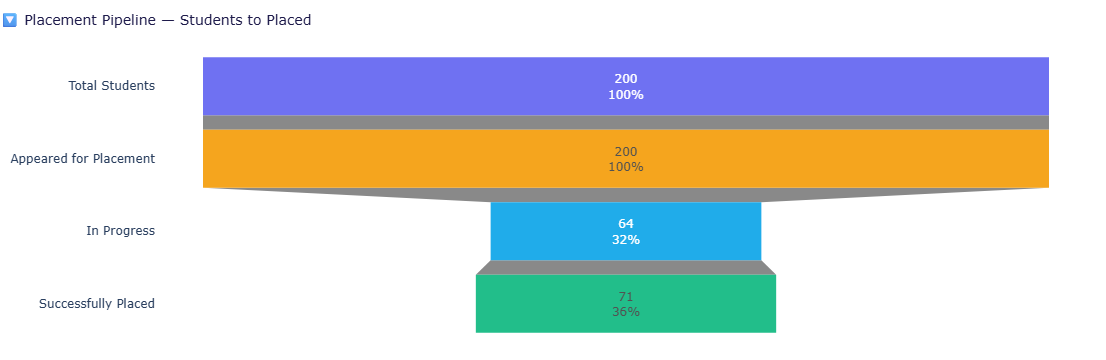

In [5]:
placement['status'] = placement['status'].astype(str).str.strip().str.title()

# 🔹 Count values safely
inprog_count = placement[placement['status'] == 'In Progress'].shape[0]
placed_count = placement[placement['status'] == 'Placed'].shape[0]

# 🔹 Funnel stages
pipeline_stages = [
    ('Total Students', len(students)),
    ('Appeared for Placement', len(placement)),
    ('In Progress', inprog_count),
    ('Successfully Placed', placed_count),
]

# 🔹 Create Funnel Chart
fig_funnel = go.Figure(go.Funnel(
    y=[stage for stage, _ in pipeline_stages],
    x=[value for _, value in pipeline_stages],
    textinfo="value+percent initial",
    marker=dict(
        color=['#6366F1', '#F59E0B', '#0EA5E9', '#10B981']
    ),
    opacity=0.92
))

# 🔹 Layout styling
fig_funnel.update_layout(
    title=dict(
        text='🔽 Placement Pipeline — Students to Placed',
        font=dict(size=14, color='#1E1B4B'),
        x=0
    ),
    margin=dict(t=50, b=20, l=10, r=10),
    paper_bgcolor='white',
    plot_bgcolor='rgba(0,0,0,0)'
)

# 🔹 Show chart
fig_funnel.show()

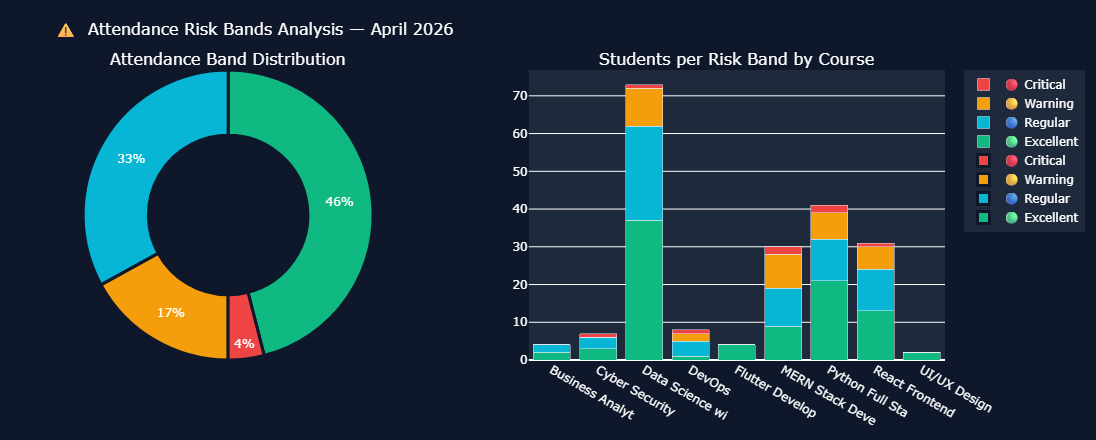

In [6]:
# ─────────────────────────────────────────────────────────────────────
# CELL 6 · ⚠️ Attendance Risk Bands
# ─────────────────────────────────────────────────────────────────────

att_bands = attendance['Status'].value_counts().reset_index()
att_bands.columns = ['band', 'count']
band_order = ['Excellent', 'Regular', 'Warning', 'Critical']
att_bands['band'] = pd.Categorical(att_bands['band'], categories=band_order, ordered=True)
att_bands = att_bands.sort_values('band')

band_colors = {'Excellent': '#10b981', 'Regular': '#06b6d4', 'Warning': '#f59e0b', 'Critical': '#ef4444'}
band_icons  = {'Excellent': '🟢', 'Regular': '🔵', 'Warning': '🟡', 'Critical': '🔴'}

fig_att = make_subplots(
    rows=1, cols=2,
    specs=[[{'type':'pie'}, {'type':'bar'}]],
    subplot_titles=('Attendance Band Distribution', 'Students per Risk Band by Course')
)

fig_att.add_trace(go.Pie(
    labels=[f"{band_icons[b]} {b}" for b in att_bands['band']],
    values=att_bands['count'],
    hole=0.55,
    marker=dict(colors=[band_colors[b] for b in att_bands['band']],
                line=dict(color='#0f172a', width=3)),
    textfont=dict(size=12, color='white'),
    showlegend=True
), row=1, col=1)

# Per-course breakdown
att_course_band = attendance.groupby(['course','Status']).size().unstack(fill_value=0).reset_index()
for band in band_order:
    if band in att_course_band.columns:
        fig_att.add_trace(go.Bar(
            name=f'{band_icons[band]} {band}',
            x=att_course_band['course'].str[:15],
            y=att_course_band[band],
            marker_color=band_colors[band],
        ), row=1, col=2)

fig_att.update_layout(
    title=dict(text='⚠️  Attendance Risk Bands Analysis — April 2026',
               font=dict(size=16, color='white')),
    barmode='stack',
    paper_bgcolor='#0f172a', plot_bgcolor='#1e293b',
    font=dict(color='white'),
    height=440, margin=dict(l=20, r=20, t=70, b=80),
    legend=dict(bgcolor='#1e293b', bordercolor='#334155'),
    xaxis2=dict(tickangle=-30, gridcolor='#334155'),
    yaxis2=dict(gridcolor='#334155')
)
fig_att.show()

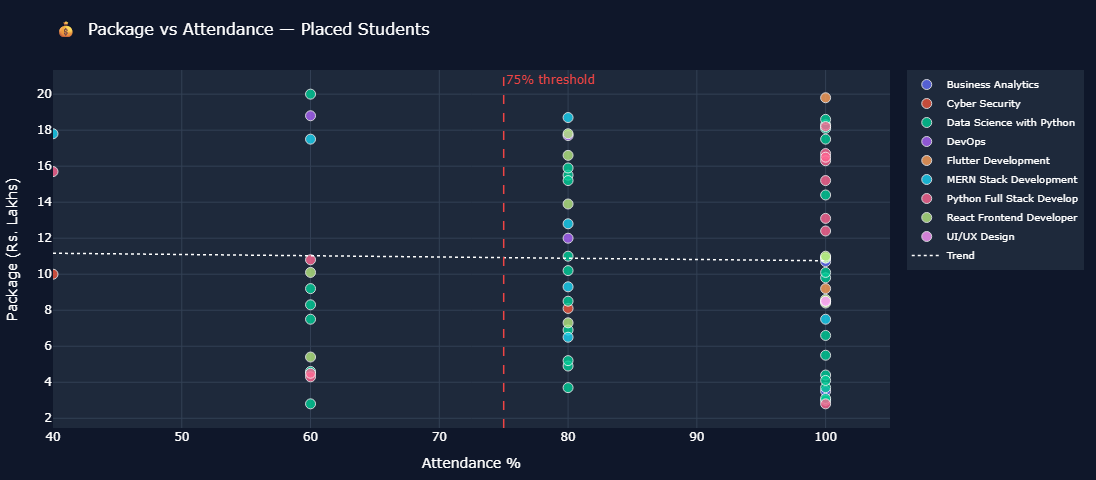

In [8]:
# ─────────────────────────────────────────────────────────────────────
# CELL 8 · 💰 Package vs Attendance Scatter
# ─────────────────────────────────────────────────────────────────────

pkg_att = placement.merge(
    attendance[['student_id', 'Attendance %']], on='student_id', how='inner'
)
pkg_att['package(Rs.L)'] = pd.to_numeric(pkg_att['package(Rs.L)'], errors='coerce')
pkg_att_placed = pkg_att[pkg_att['status'] == 'Placed'].dropna(subset=['package(Rs.L)'])

fig_scatter = go.Figure()

for course_name, grp in pkg_att_placed.groupby('course'):
    fig_scatter.add_trace(go.Scatter(
        x=grp['Attendance %'], y=grp['package(Rs.L)'],
        mode='markers',
        name=course_name[:25],
        marker=dict(size=10, opacity=0.8, line=dict(width=1, color='white')),
        hovertemplate=('<b>%{text}</b><br>Attendance: %{x}%<br>Package: ₹%{y}L'
                       '<extra>' + course_name + '</extra>'),
        text=grp['student_name']
    ))

# Trend line
x_all = pkg_att_placed['Attendance %'].values
y_all = pkg_att_placed['package(Rs.L)'].values
z = np.polyfit(x_all, y_all, 1)
p = np.poly1d(z)
x_line = np.linspace(x_all.min(), x_all.max(), 100)
fig_scatter.add_trace(go.Scatter(
    x=x_line, y=p(x_line),
    mode='lines', name='Trend',
    line=dict(color='white', width=1.5, dash='dot'),
    showlegend=True
))

fig_scatter.add_vline(x=75, line=dict(color='#ef4444', dash='dash', width=1.5),
    annotation_text='75% threshold', annotation_font_color='#ef4444')

fig_scatter.update_layout(
    title=dict(text='💰  Package vs Attendance — Placed Students',
               font=dict(size=16, color='white')),
    paper_bgcolor='#0f172a', plot_bgcolor='#1e293b',
    font=dict(color='white'),
    xaxis=dict(title='Attendance %', gridcolor='#334155', range=[40, 105]),
    yaxis=dict(title='Package (Rs. Lakhs)', gridcolor='#334155'),
    height=480, margin=dict(l=20, r=20, t=70, b=40),
    legend=dict(bgcolor='#1e293b', bordercolor='#334155', font=dict(size=10))
)
fig_scatter.show()

In [9]:
# ─────────────────────────────────────────────────────────────────────
# CELL 9 · 📍 Intake by Location (Geo Bar)
# ─────────────────────────────────────────────────────────────────────

loc_adm = admissions[admissions['status']=='Admitted'].groupby('location').size().reset_index(name='admitted')
loc_all = admissions.groupby('location').size().reset_index(name='total')
loc_data = loc_all.merge(loc_adm, on='location', how='left').fillna(0)
loc_data['conversion'] = (loc_data['admitted'] / loc_data['total'] * 100).round(1)
loc_data = loc_data.sort_values('total', ascending=True)

fig_loc = go.Figure()
fig_loc.add_trace(go.Bar(
    name='Enquiries',
    y=loc_data['location'], x=loc_data['total'],
    orientation='h',
    marker=dict(color='#334155', line=dict(width=0)),
))
fig_loc.add_trace(go.Bar(
    name='Admitted',
    y=loc_data['location'], x=loc_data['admitted'],
    orientation='h',
    marker=dict(color='#6366f1', line=dict(width=0)),
    text=[f'{c}%' for c in loc_data['conversion']],
    textposition='outside',
    textfont=dict(color='#06b6d4', size=11)
))

fig_loc.update_layout(
    title=dict(text='📍  Intake by Location — Enquiries vs Admissions',
               font=dict(size=16, color='white')),
    barmode='overlay',
    paper_bgcolor='#0f172a', plot_bgcolor='#1e293b',
    font=dict(color='white'),
    xaxis=dict(title='Count', gridcolor='#334155'),
    yaxis=dict(gridcolor='#334155'),
    height=380, margin=dict(l=20, r=80, t=70, b=40),
    legend=dict(bgcolor='#1e293b', bordercolor='#334155')
)
fig_loc.show()

In [10]:
# ─────────────────────────────────────────────────────────────────────
# CELL 10 · 🏫 Classroom Slots Heatmap
# ─────────────────────────────────────────────────────────────────────

slot_cols = ['10:00-12:00', '12:00-02:00', '02:30-04:30', '04:30-05:30']
cls_clean = classroom.copy()
cls_clean.index = cls_clean['CID']

heat_matrix = cls_clean[slot_cols].applymap(lambda x: 1 if str(x).strip() != '' else 0)
hover_text  = cls_clean[slot_cols].applymap(lambda x: str(x).strip() if str(x).strip() else 'Empty')

fig_cls = go.Figure(go.Heatmap(
    z=heat_matrix.values,
    x=slot_cols,
    y=list(cls_clean.index),
    text=hover_text.values,
    texttemplate='%{text}',
    textfont=dict(size=11, color='white'),
    colorscale=[[0, '#1e293b'], [1, '#6366f1']],
    showscale=False,
    hovertemplate='Room: %{y}<br>Slot: %{x}<br>Batch: %{text}<extra></extra>'
))

fig_cls.update_layout(
    title=dict(text='🏫  Classroom Slot Utilisation — All Rooms',
               font=dict(size=16, color='white')),
    paper_bgcolor='#0f172a', plot_bgcolor='#1e293b',
    font=dict(color='white'),
    xaxis=dict(title='Time Slot', gridcolor='#334155', side='top'),
    yaxis=dict(title='Classroom', gridcolor='#334155'),
    height=340, margin=dict(l=20, r=20, t=90, b=20)
)
fig_cls.show()

In [14]:
admissions

,admission_id,student_id,student_name,mobile_no,email,location,qualification,course,mode,admission_date,attended_by,status
0,ADM0001,STU0001,Kiran,9765861654,kiran1@gmail.com,Palakkad,Working Professional,MERN Stack Development,Offline,1/2/2025,Shivaprasad,Admitted
1,ADM0002,STU0002,Tanya,9699233469,tanya2@gmail.com,Palakkad,UG,Data Science with Python,Offline,1/2/2025,Baiju,Admitted
2,ADM0003,STU0003,Faisal,9190014738,faisal3@gmail.com,Palakkad,Working Professional,Data Science with Python,Online,1/2/2025,Rifana,Admitted
3,ADM0004,STU0004,Ajay,9819774813,ajay4@gmail.com,Kottayam,UG,Python Full Stack Development,Online,1/2/2025,Praveena,Admitted
4,ADM0005,STU0005,Rahul,9385106179,rahul5@gmail.com,Kottayam,PG,MERN Stack Development,Offline,1/3/2025,Baiju,Admitted
...,...,...,...,...,...,...,...,...,...,...,...,...
469,ADM0470,STU0470,Nihal Raj,9552791148,nihal.raj470@gmail.com,Kochi,UG,Digital Marketing,Offline,9/14/2024,Praveena,Not Admitted
470,ADM0471,STU0471,Ameen Nair,9586101490,ameen.nair471@gmail.com,Trivandrum,Working Professional,Python Full Stack Development,Offline,9/15/2024,Shivaprasad,Not Admitted
471,ADM0472,STU0472,Jasim K,9715201830,jasim.k472@gmail.com,Kochi,Working Professional,Python Full Stack Development,Offline,9/16/2024,Rifana,Not Admitted
472,ADM0473,STU0473,Sreya P,9965712098,sreya.p473@gmail.com,Trivandrum,Working Professional,DevOps,Offline,9/17/2024,Baiju,Not Admitted


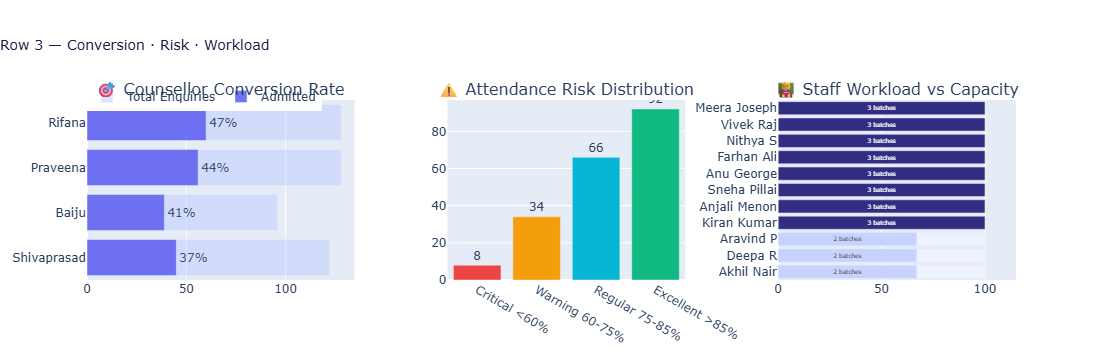

In [17]:

# ═══════════════════════════════════════════════════════════════════════════════
# ROW 3 — Counsellor Conversion · Attendance Risk · Staff Workload
# ═══════════════════════════════════════════════════════════════════════════════

fig_row3 = make_subplots(
    rows=1, cols=3,
    subplot_titles=[
        '🎯 Counsellor Conversion Rate',
        '⚠️ Attendance Risk Distribution',
        '👩‍🏫 Staff Workload vs Capacity',
    ],
    column_widths=[0.36, 0.32, 0.32],
    horizontal_spacing=0.1,
)

# ── 3A: Counsellor Conversion ────────────────────────────────────────────────
total_by = admissions.groupby('attended_by').size()
admit_by = admissions[admissions['status']=='Admitted'].groupby('attended_by').size()
conv_df  = pd.DataFrame({
    'Counsellor': total_by.index,
    'Total':      total_by.values,
    'Admitted':   admit_by.reindex(total_by.index, fill_value=0).values,
})
conv_df['Conv%'] = (conv_df['Admitted'] / conv_df['Total'] * 100).round(1)
conv_df = conv_df.sort_values('Conv%', ascending=True)

fig_row3.add_trace(go.Bar(
    y=conv_df['Counsellor'], x=conv_df['Total'],
    name='Total Enquiries', orientation='h',
    marker_color='#C7D2FE', opacity=0.6, showlegend=True,
), row=1, col=1)
fig_row3.add_trace(go.Bar(
    y=conv_df['Counsellor'], x=conv_df['Admitted'],
    name='Admitted', orientation='h',
    marker_color='#6366F1', opacity=0.9,
    text=conv_df['Conv%'].apply(lambda v: f'{v:.0f}%'),
    textposition='outside', showlegend=True,
), row=1, col=1)
fig_row3.update_layout(barmode='overlay')

# ── 3B: Attendance Risk Bands ────────────────────────────────────────────────
risk_bins   = [0, 60, 75, 85, 101]
risk_labels = ['Critical\n<60%', 'Warning\n60-75%', 'Regular\n75-85%', 'Excellent\n>85%']
risk_colors = ['#EF4444', '#F59E0B', '#06B6D4', '#10B981']
att_risk = pd.cut(
    attendance['Attendance %'], bins=risk_bins,
    labels=risk_labels, right=False
).value_counts().reindex(risk_labels).fillna(0).reset_index()
att_risk.columns = ['Risk Band', 'Students']

fig_row3.add_trace(go.Bar(
    x=att_risk['Risk Band'], y=att_risk['Students'],
    marker_color=risk_colors,
    text=att_risk['Students'].astype(int),
    textposition='outside',
    showlegend=False,
), row=1, col=2)

# ── 3C: Staff Workload ───────────────────────────────────────────────────────
staff_ov = staff[staff['batches_handling'] > 0].copy()
staff_ov['capacity_pct'] = (staff_ov['batches_handling'] / 3 * 100).round(0)
staff_ov = staff_ov.sort_values('capacity_pct', ascending=True)

fig_row3.add_trace(go.Bar(
    y=staff_ov['name'], x=[100]*len(staff_ov),
    orientation='h', marker_color='#EEF2FF',
    showlegend=False, hoverinfo='skip',
), row=1, col=3)
fig_row3.add_trace(go.Bar(
    y=staff_ov['name'], x=staff_ov['capacity_pct'],
    orientation='h',
    marker=dict(
        color=staff_ov['capacity_pct'].tolist(),
        colorscale=[[0,'#C7D2FE'],[0.5,'#6366F1'],[1,'#312E81']],
        showscale=False,
    ),
    text=staff_ov['batches_handling'].apply(lambda v: f'{int(v)} batches'),
    textposition='inside', insidetextanchor='middle',
    showlegend=False,
    hovertemplate='%{y}<br>Load: %{x:.0f}%<extra></extra>',
), row=1, col=3)

fig_row3.update_layout(
    barmode='overlay',
    title=dict(text='Row 3 — Conversion · Risk · Workload', font=dict(size=14, color='#1E1B4B'), x=0),
    legend=dict(orientation='h', y=1.1, x=0),
)

fig_row3.update_xaxes(range=[0, 115], row=1, col=3)
fig_row3.show()


In [18]:
# ─────────────────────────────────────────────────────────────────────
# CELL 13 · 📄 Institute At a Glance (Summary Table)
# ─────────────────────────────────────────────────────────────────────

summary_data = [
    ['👩‍🎓 Total Students',       str(total_students),   'Active enrolled students'],
    ['📋 Total Enquiries',       str(total_enquiries),  'Admission enquiries received'],
    ['✅ Admitted',              str(admitted),         f'Admission rate: {adm_rate}%'],
    ['🎯 Placed Students',       str(placed),           f'Placement rate: {placed_pct}%'],
    ['🔄 In Progress',           str((placement['status']=='In Progress').sum()), 'Placement in pipeline'],
    ['📊 Avg Attendance',        f'{avg_att}%',         'April 2026 month-to-date'],
    ['⚠️ Below 75% Att.',        str(below_75),         'Students at risk'],
    ['💰 Avg Package',           f'₹{avg_pkg}L',        'Placed students average CTC'],
    ['🏫 Classroom Fill',        f'{room_fill_pct}%',   f'{filled_slots}/{total_slots} slots filled'],
    ['📚 Total Batches',         str(int(total_batches)), 'Active course batches'],
    ['👨‍🏫 Teaching Staff',        str(len(teaching_staff)), 'Active trainers'],
    ['🏙️ Locations',             str(admissions['location'].nunique()), 'Cities covered'],
]

fig_tbl = go.Figure(go.Table(
    columnwidth=[200, 100, 250],
    header=dict(
        values=['<b>Metric</b>', '<b>Value</b>', '<b>Note</b>'],
        fill_color='#4338ca',
        font=dict( color='white',size=13, family='Georgia'),
        align='left', height=36
    ),
    cells=dict(
        values=list(zip(*summary_data)),
        
        font=dict( size=12),
        align='left', height=32
    )
))

fig_tbl.update_layout(
    title=dict(text='📄  Institute At a Glance — Full Summary',
               font=dict(size=16)),
    
    height=500, margin=dict(l=20, r=20, t=70, b=20)
)
fig_tbl.show()
print('\n✅ All visualisations rendered successfully! Institute Command Centre ready.')

NameError: name 'teaching_staff' is not defined